# GSFM Paired PPI

In this notebook we explore ways of adapting GSFM to predicting protein-protein interactions.

## ETL

### Imports

In [ ]:
# install GSFM into colab
!pip install 'gsfm@git+https://github.com/MaayanLab/gsfm.git'

  Cloning https://github.com/MaayanLab/gsfm.git to /tmp/pip-install-zzpygjf8/gsfm_c264f29cf5624486b4c42efdaa1b6854
  Running command git clone --filter=blob:none --quiet https://github.com/MaayanLab/gsfm.git /tmp/pip-install-zzpygjf8/gsfm_c264f29cf5624486b4c42efdaa1b6854
  Resolved https://github.com/MaayanLab/gsfm.git to commit 6fa587969aa218f382887b7d033c4ef77f05cc76
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


In [ ]:
import torch
import random
import pandas as pd
import numpy as np
import traceback
from matplotlib import pyplot as plt
from sklearn import linear_model, metrics, model_selection
from tqdm.auto import tqdm
from gsfm import Vocab, GSFM

In [ ]:
device = 'cuda'

In [ ]:
# load gsfm vocabulary and model weights
vocab = Vocab.from_pretrained('maayanlab/gsfm-rummagene')
gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene').to(device)
gsfm.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


GSFM(
  (encoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=19589, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (decoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=19589, bias=True)
    )
  )
)

### Load PPI Database

In [ ]:
# Load PPI from Harmonizome "Pathway Commons"
# https://maayanlab.cloud/Harmonizome/dataset/Pathway+Commons+Protein-Protein+Interactions
df = pd.read_csv('https://maayanlab.cloud/static/hdfs/harmonizome/data/pc/gene_attribute_matrix.txt.gz', sep='\t', index_col=[0,1,2], header=[0,1,2])
df

,,#,RETSAT,C1orf131,TPMT,METTL8,DYNLRB2,DNAH14,C9orf41,RSPH3,WARS2,PDDC1,...,SYT16,UTS2R,TAS1R1,TAS1R2,OR1G1,FLRT1,ARTN,C10orf95,OBP2A,GPHA2
,,#,na,na,na,na,na,na,na,na,na,na,...,na,na,na,na,na,na,na,na,na,na
,,GeneSym,54884,128061,7172,79828,83657,127602,138199,83861,10352,347862,...,83851,2837,80835,80834,8390,23769,9048,79946,29991,170589
RETSAT,na,54884,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C1orf131,na,128061,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPMT,na,7172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
METTL8,na,79828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DYNLRB2,na,83657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FLRT1,na,23769,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ARTN,na,9048,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Simplify column/index to gene names
df.index = df.index.get_level_values(0)
df.columns = df.columns.get_level_values(0)
df

#,RETSAT,C1orf131,TPMT,METTL8,DYNLRB2,DNAH14,C9orf41,RSPH3,WARS2,PDDC1,...,SYT16,UTS2R,TAS1R1,TAS1R2,OR1G1,FLRT1,ARTN,C10orf95,OBP2A,GPHA2
RETSAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C1orf131,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPMT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
METTL8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DYNLRB2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FLRT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ARTN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C10orf95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OBP2A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Align

In [ ]:
# Find gene names not present in GSFM
aligned_tokens = np.array(vocab(df.index))!=0
(~aligned_tokens).sum()

np.int64(1016)

In [ ]:
# Ignore gene names not present in GSFM
df = df.loc[aligned_tokens, aligned_tokens]
df

#,RETSAT,TPMT,METTL8,DYNLRB2,DNAH14,RSPH3,WARS2,HOXC6,CHAC2,TPRA1,...,NPW,SYT16,UTS2R,TAS1R1,TAS1R2,OR1G1,FLRT1,ARTN,OBP2A,GPHA2
RETSAT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TPMT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
METTL8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DYNLRB2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DNAH14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OR1G1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
FLRT1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ARTN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
OBP2A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Predict PPIs

In [ ]:
token_ids = torch.tensor(vocab(df.columns)).to(device)

In [ ]:
np.random.seed(0)
# k random protein pairs
k = 50_000
i = random.choices(np.arange(df.shape[0]), k=k)
j = random.choices(np.arange(df.shape[0]), k=k)
# is there a known interaction between these two proteins?
y = df.values[i, j]

In [ ]:
pd.Series(y).value_counts()

,count
0.0,49233
1.0,767


### Version 1: Create GSFM gene embeddings with single genes as the set for linear model

In [ ]:
# we create a column vector that-is one gene in each and encode them all with GSFM
gene_embed = gsfm.encode(token_ids[:, None]).cpu().detach().numpy()
gene_embed.shape

(14731, 256)

In [ ]:
# gene embeddings for all pairs
X = np.concatenate([gene_embed[i, :], gene_embed[j, :]], axis=1)
X.shape

(50000, 512)

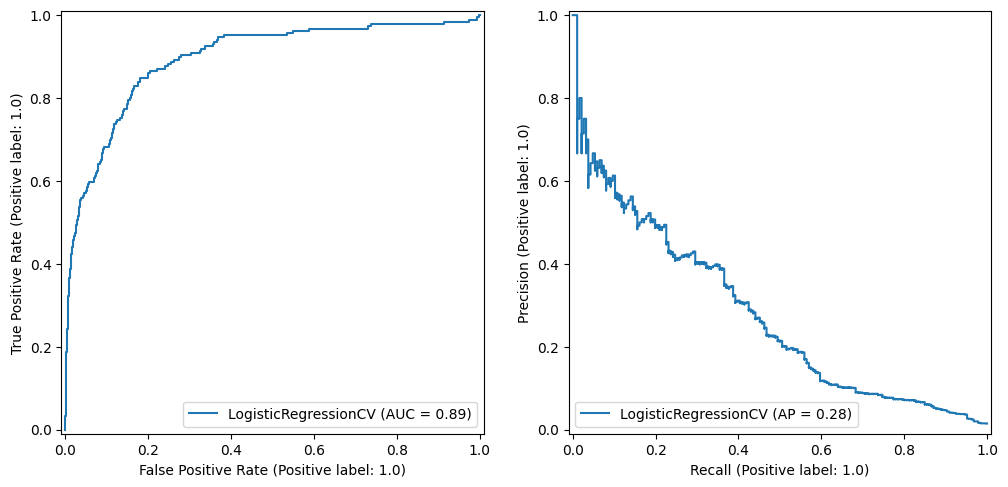

In [ ]:
# Train a linear model to classify protein protein interactions
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=0)
model = linear_model.LogisticRegressionCV()
model.fit(X_train, y_train)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1)
metrics.PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax2)
plt.show()

### Version 2: Use GSFM to obtain paired gene embedings for linear model

In [ ]:
token_id_pairs = torch.concat([token_ids[i][:, None], token_ids[j][:, None]], 1)
token_id_pairs

tensor([[ 8847,  1209],
        [ 6515,  8851],
        [  653, 13046],
        ...,
        [ 5446,  5287],
        [ 7726,  6237],
        [ 3969,  5363]], device='cuda:0')

In [ ]:
# gene embeddings for all pairs
X = gsfm.encode(token_id_pairs).cpu().detach().numpy()
X.shape

(50000, 256)

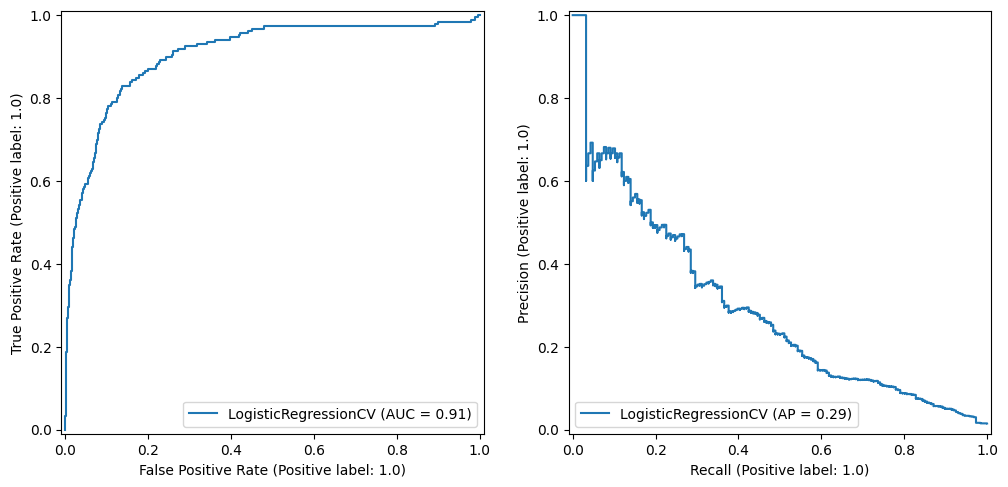

In [ ]:
# Train a linear model to classify protein protein interactions
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=0)
model = linear_model.LogisticRegressionCV()
model.fit(X_train, y_train)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1)
metrics.PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax2)
plt.show()

### Version 3: Use GSFM on paired genes with final layer features for linear model

In [ ]:
gsfm

GSFM(
  (encoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=19589, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (decoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=19589, bias=True)
    )
  )
)

In [ ]:
gsfm.decoder.layers = torch.nn.ModuleList(list(list(list(gsfm.children())[-1].children())[0].children())[:-1])
gsfm

GSFM(
  (encoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=19589, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=512, out_features=256, bias=True)
    )
  )
  (decoder): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
  )
)

In [ ]:
# gene embeddings for all pairs
X = gsfm(token_id_pairs).cpu().detach().numpy()
X.shape

(50000, 256)

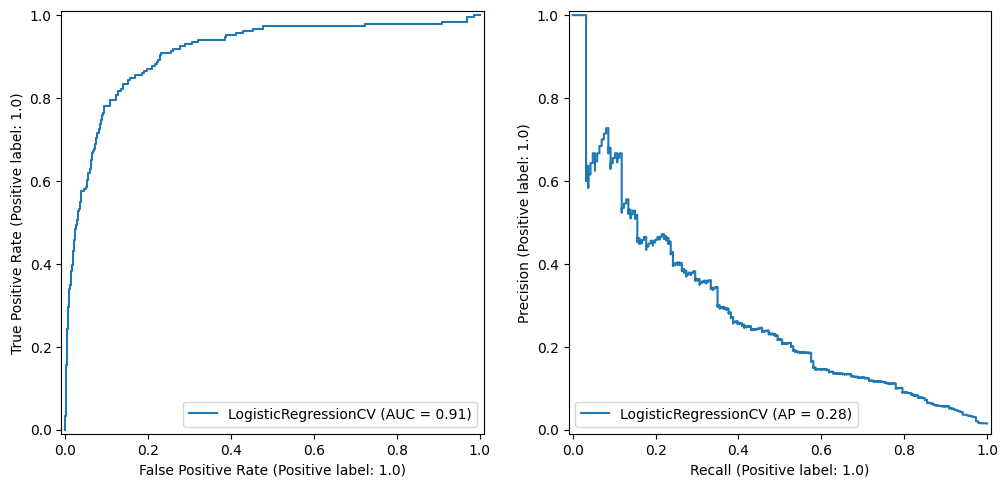

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, random_state=0)
model = linear_model.LogisticRegressionCV()
model.fit(X_train, y_train)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1)
metrics.PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax2)
plt.show()

### Version 4: GSFM finetune decoder + classifier

In [ ]:
import lightning as L

gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene').to(device)
gsfm.eval()

class GSFM_PPI(L.LightningModule):
  def __init__(self):
    super().__init__()
    self.decoder = gsfm.decoder
    self.decoder.layers = torch.nn.ModuleList(
      list(self.decoder.layers.children())[:-1]
    )
    self.decoder.train()
    self.classifier = torch.nn.Linear(256, 1)

  def forward(self, x):
    x = gsfm.encode(x)
    x = self.decoder(x)
    y = self.classifier(x)
    return y

  def training_step(self, batch, batch_idx):
    x, y = batch
    y_ = self(x)
    criterion = torch.nn.BCEWithLogitsLoss()
    loss = criterion(y_, y)
    self.log('loss', loss, prog_bar=True)
    return loss

  def validation_step(self, batch, batch_idx):
    return self.training_step(batch, batch_idx)

  def configure_optimizers(self):
    optimizer = torch.optim.Adam((*self.parameters(), *gsfm.parameters()))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.25)
    return [optimizer], [{
        "scheduler": scheduler,
        "monitor": "loss",
        "frequency": 1,
    }]

X_train, X_test, y_train, y_test = model_selection.train_test_split(token_id_pairs, y, random_state=0)

class PPIData(L.LightningDataModule):
  def train_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, torch.tensor(y_train[:, None])), batch_size=32)
  def test_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test, torch.tensor(y_test[:, None])), batch_size=32)

gsfm_ppi = GSFM_PPI().to(device)
L.Trainer(max_epochs=20).fit(gsfm_ppi, datamodule=PPIData())

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - 

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ decoder    │ MLP    │ 65.8 K │ train │     0 │
│ 1 │ classifier │ Linear │    257 │ train │     0 │
└───┴────────────┴────────┴────────┴───────┴───────┘

Trainable params: 66.0 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 66.0 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 6                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


/tmp/ipython-input-2739879305.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = torch.nn.functional.sigmoid(gsfm_ppi(torch.tensor(X_test).to(device))).detach().cpu().numpy()


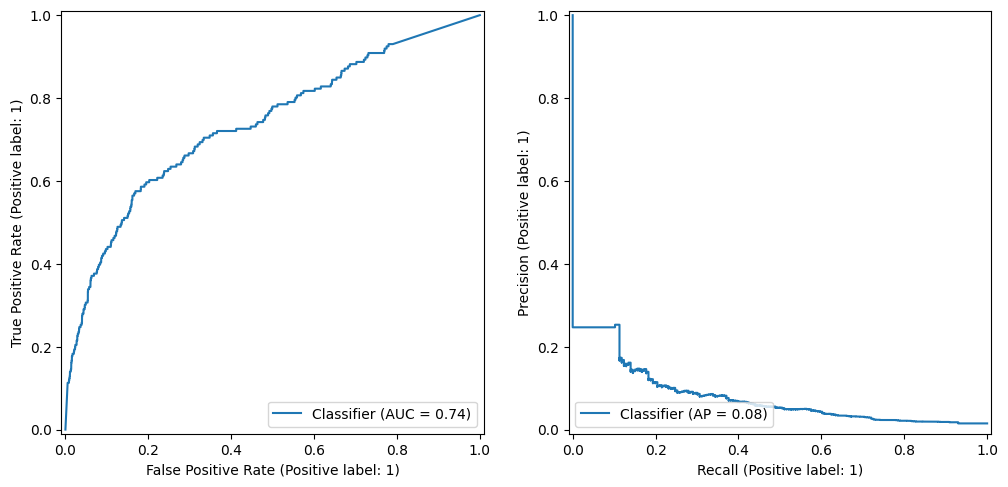

In [ ]:
gsfm_ppi.eval()
gsfm_ppi = gsfm_ppi.to(device)
y_pred = torch.nn.functional.sigmoid(gsfm_ppi(torch.tensor(X_test).to(device))).detach().cpu().numpy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_predictions(y_test, y_pred, ax=ax1)
metrics.PrecisionRecallDisplay.from_predictions(y_test, y_pred, ax=ax2)
plt.show()

### Version 5: GSFM finetune all layers

In [ ]:
import lightning as L

gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene').to(device)

class GSFM_PPI(L.LightningModule):
  def __init__(self):
    super().__init__()
    self.gsfm = gsfm
    self.gsfm.decoder.layers = torch.nn.ModuleList(
      list(self.gsfm.decoder.layers.children())[:-1]
    )
    self.classifier = torch.nn.Linear(256, 1)

  def forward(self, x):
    x = self.gsfm.encode(x)
    y = self.classifier(x)
    return y

  def training_step(self, batch, batch_idx):
    x, y = batch
    y_ = self(x)
    criterion = torch.nn.BCEWithLogitsLoss()
    loss = criterion(y_, y)
    self.log('loss', loss, prog_bar=True)
    return loss

  def validation_step(self, batch, batch_idx):
    return self.training_step(batch, batch_idx)

  def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.25)
    return [optimizer], [{
        "scheduler": scheduler,
        "monitor": "loss",
        "frequency": 1,
    }]

X_train, X_test, y_train, y_test = model_selection.train_test_split(token_id_pairs, y, random_state=0)

class PPIData(L.LightningDataModule):
  def train_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, torch.tensor(y_train[:, None])), batch_size=32)
  def test_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test, torch.tensor(y_test[:, None])), batch_size=32)

gsfm_ppi = GSFM_PPI().to(device)
L.Trainer(max_epochs=20).fit(gsfm_ppi, datamodule=PPIData())

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - 

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ gsfm       │ GSFM   │ 10.2 M │ train │     0 │
│ 1 │ classifier │ Linear │    257 │ train │     0 │
└───┴────────────┴────────┴────────┴───────┴───────┘

Trainable params: 10.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.2 M                                                                                               
Total estimated model params size (MB): 40                                                                         
Modules in train mode: 13                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


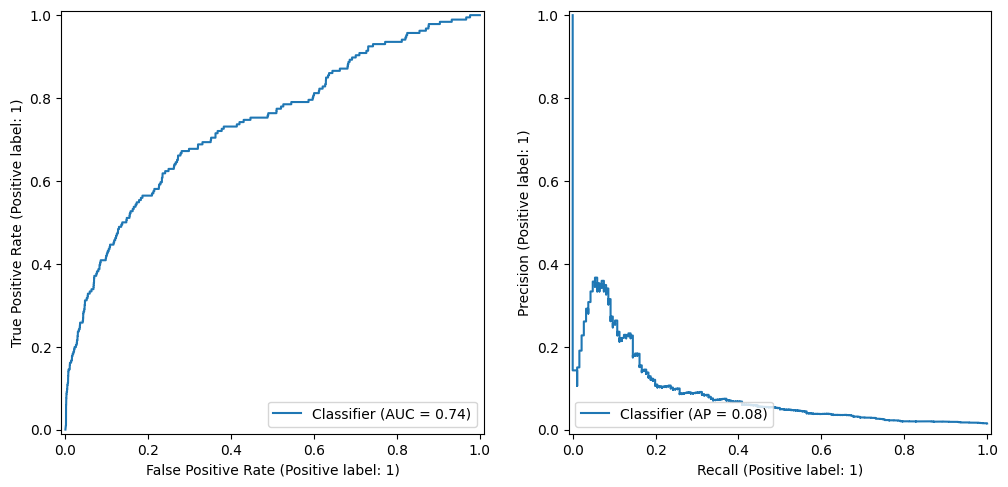

In [ ]:
gsfm_ppi.eval()
gsfm_ppi = gsfm_ppi.to(device)
y_pred = torch.nn.functional.sigmoid(gsfm_ppi(X_test.to(device))).detach().cpu().numpy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_predictions(y_test, y_pred, ax=ax1)
metrics.PrecisionRecallDisplay.from_predictions(y_test, y_pred, ax=ax2)
plt.show()

### Version 6: Train Classifier to use GSFM predictions

In [ ]:
import lightning as L

gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene').to(device)
gsfm.eval()

class GSFM_PPI(L.LightningModule):
  def __init__(self):
    super().__init__()
    self.classifier = torch.nn.Linear(gsfm.decoder.layers[-1].out_features, 1)

  def forward(self, x):
    x = gsfm(x)
    y = self.classifier(x)
    return y

  def training_step(self, batch, batch_idx):
    x, y = batch
    y_ = self(x)
    criterion = torch.nn.BCEWithLogitsLoss()
    loss = criterion(y_, y)
    self.log('loss', loss, prog_bar=True)
    return loss

  def validation_step(self, batch, batch_idx):
    return self.training_step(batch, batch_idx)

  def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.25)
    return [optimizer], [{
        "scheduler": scheduler,
        "monitor": "loss",
        "frequency": 1,
    }]

X_train, X_test, y_train, y_test = model_selection.train_test_split(token_id_pairs, y, random_state=0)

class PPIData(L.LightningDataModule):
  def train_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, torch.tensor(y_train[:, None], device=device)), batch_size=32)
  def test_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test, torch.tensor(y_test[:, None], device=device)), batch_size=32)

gsfm_ppi = GSFM_PPI().to(device)
L.Trainer(max_epochs=20).fit(gsfm_ppi, datamodule=PPIData())

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - 

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ classifier │ Linear │ 19.6 K │ train │     0 │
└───┴────────────┴────────┴────────┴───────┴───────┘

Trainable params: 19.6 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 19.6 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


/tmp/ipython-input-1307015034.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = torch.nn.functional.sigmoid(gsfm_ppi(torch.tensor(X_test, device=device))).detach().cpu().numpy()


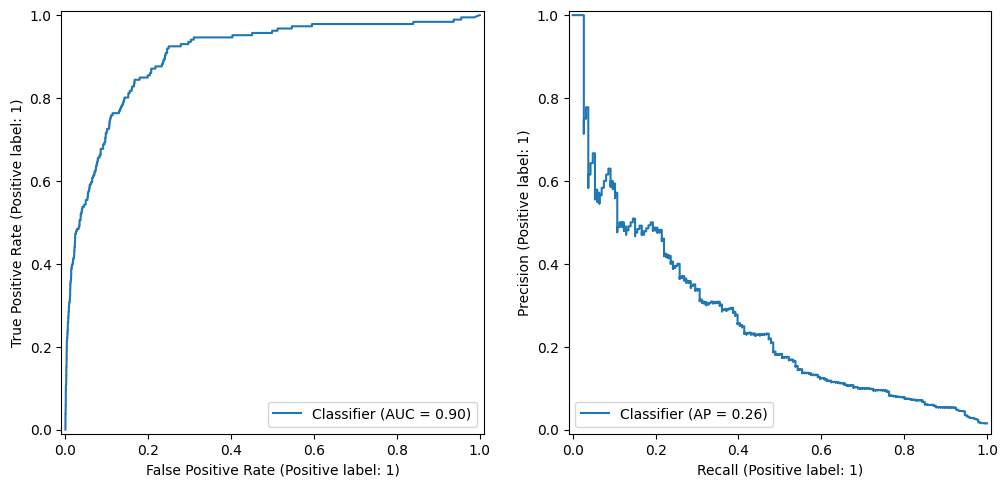

In [ ]:
gsfm_ppi.eval()
gsfm_ppi = gsfm_ppi.to(device)
y_pred = torch.nn.functional.sigmoid(gsfm_ppi(torch.tensor(X_test, device=device))).detach().cpu().numpy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_predictions(y_test, y_pred, ax=ax1)
metrics.PrecisionRecallDisplay.from_predictions(y_test, y_pred, ax=ax2)
plt.show()

### Version 7: GSFM 2-layer classifier head

In [ ]:
import lightning as L

gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene').to(device)
gsfm.eval()
gsfm.decoder.layers = torch.nn.ModuleList(
  list(gsfm.decoder.layers.children())[:-1]
)

class GSFM_PPI(L.LightningModule):
  def __init__(self):
    super().__init__()
    self.classifier = torch.nn.Sequential(
        torch.nn.Linear(256, 512),
        torch.nn.ReLU(),
        torch.nn.Linear(512, 1),
    )

  def forward(self, x):
    x = gsfm(x)
    y = self.classifier(x)
    return y

  def training_step(self, batch, batch_idx):
    x, y = batch
    y_ = self(x)
    criterion = torch.nn.BCEWithLogitsLoss()
    loss = criterion(y_, y)
    self.log('loss', loss, prog_bar=True)
    return loss

  def validation_step(self, batch, batch_idx):
    return self.training_step(batch, batch_idx)

  def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.25)
    return [optimizer], [{
        "scheduler": scheduler,
        "monitor": "loss",
        "frequency": 1,
    }]

X_train, X_test, y_train, y_test = model_selection.train_test_split(token_id_pairs, y, random_state=0)

class PPIData(L.LightningDataModule):
  def train_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, torch.tensor(y_train[:, None], device=device)), batch_size=32)
  def test_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test, torch.tensor(y_test[:, None], device=device)), batch_size=32)

gsfm_ppi = GSFM_PPI().to(device)
L.Trainer(max_epochs=20).fit(gsfm_ppi, datamodule=PPIData())

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - 

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ classifier │ Sequential │  132 K │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 132 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 132 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 4                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


/tmp/ipython-input-2739879305.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred = torch.nn.functional.sigmoid(gsfm_ppi(torch.tensor(X_test).to(device))).detach().cpu().numpy()


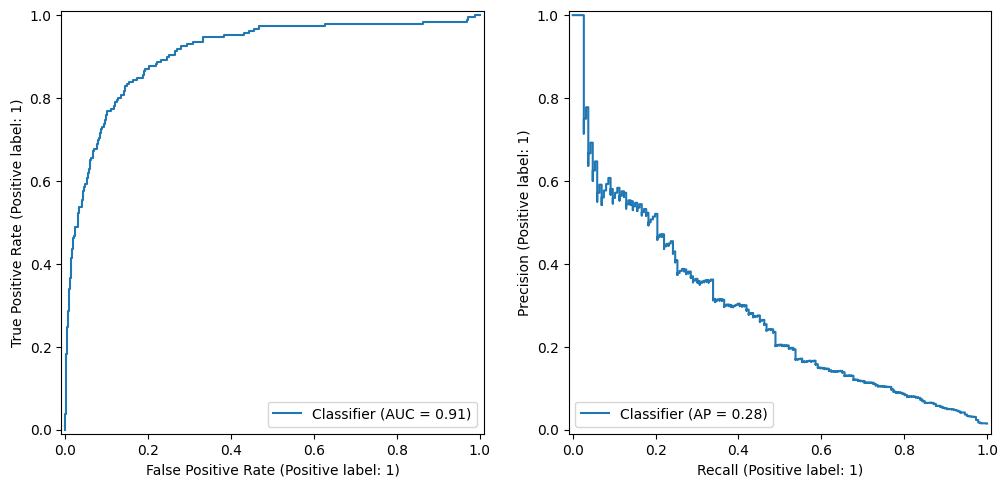

In [ ]:
gsfm_ppi.eval()
gsfm_ppi = gsfm_ppi.to(device)
y_pred = torch.nn.functional.sigmoid(gsfm_ppi(torch.tensor(X_test).to(device))).detach().cpu().numpy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_predictions(y_test, y_pred, ax=ax1)
metrics.PrecisionRecallDisplay.from_predictions(y_test, y_pred, ax=ax2)
plt.show()

### Version 8: GSFM classifier head only

In [ ]:
import lightning as L

gsfm = GSFM.from_pretrained('maayanlab/gsfm-rummagene').to(device)
gsfm.eval()
gsfm.decoder.layers = torch.nn.ModuleList(
  list(gsfm.decoder.layers.children())[:-1]
)

class GSFM_PPI(L.LightningModule):
  def __init__(self):
    super().__init__()
    self.classifier = torch.nn.Linear(256, 1)

  def forward(self, x):
    x = gsfm.encode(x.to(gsfm.device))
    x = gsfm.decoder(x)
    y = self.classifier(x.to(self.device))
    return y

  def training_step(self, batch, batch_idx):
    x, y = batch
    y_ = self(x)
    criterion = torch.nn.BCEWithLogitsLoss()
    loss = criterion(y_, y)
    self.log('loss', loss, prog_bar=True)
    return loss

  def validation_step(self, batch, batch_idx):
    return self.training_step(batch, batch_idx)

  def configure_optimizers(self):
    optimizer = torch.optim.Adam(self.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.25)
    return [optimizer], [{
        "scheduler": scheduler,
        "monitor": "loss",
        "frequency": 1,
    }]

X_train, X_test, y_train, y_test = model_selection.train_test_split(token_id_pairs, y, random_state=0)

class PPIData(L.LightningDataModule):
  def train_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, torch.tensor(y_train[:, None], device='cuda')), batch_size=32)
  def test_dataloader(self):
    return torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_test, torch.tensor(y_test[:, None], device='cuda')), batch_size=32)

gsfm_ppi = GSFM_PPI().to(device)
L.Trainer(max_epochs=20).fit(gsfm_ppi, datamodule=PPIData())

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - 

┏━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ classifier │ Linear │    257 │ train │     0 │
└───┴────────────┴────────┴────────┴───────┴───────┘

Trainable params: 257                                                                                              
Non-trainable params: 0                                                                                            
Total params: 257                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 1                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


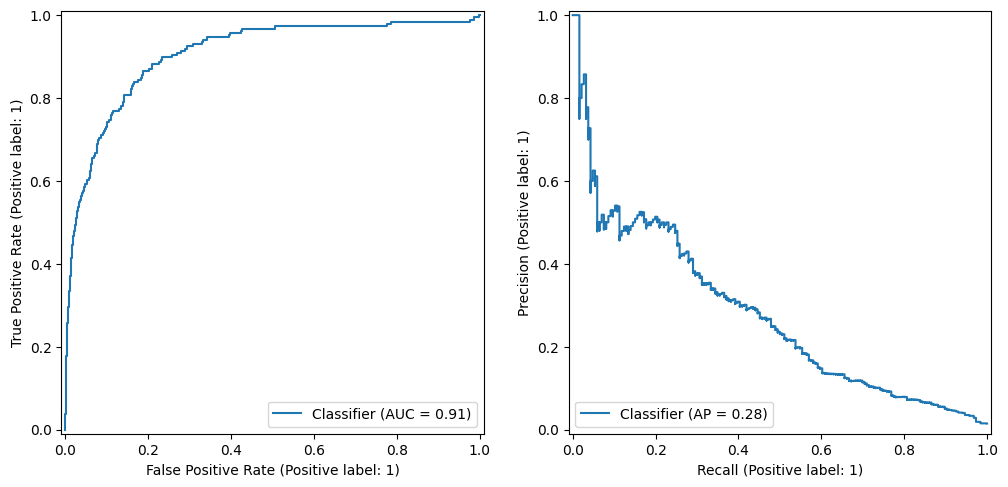

In [ ]:
gsfm_ppi.eval()
gsfm_ppi = gsfm_ppi.to(device)
y_pred = torch.nn.functional.sigmoid(gsfm_ppi(X_test.to(device))).detach().cpu().numpy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
metrics.RocCurveDisplay.from_predictions(y_test, y_pred, ax=ax1)
metrics.PrecisionRecallDisplay.from_predictions(y_test, y_pred, ax=ax2)
plt.show()

### Predictions

In [ ]:
import itertools
import scipy.special
class IterDataset(torch.utils.data.IterableDataset):
  def __init__(self, fn):
    self.fn = fn
  def __iter__(self):
    return self.fn()

X_predicted = []
y_scored = []
for X_test_ind in torch.utils.data.DataLoader(
    IterDataset(lambda: map(torch.tensor, tqdm(itertools.combinations(range(df.shape[0]), 2), total=scipy.special.comb(df.shape[0], 2)))),
    batch_size=4096,
):
  X_test = token_ids[X_test_ind]
  y_pred = torch.squeeze(torch.nn.functional.sigmoid(gsfm_ppi(X_test.to(device)))).detach().cpu().numpy()
  if (y_pred>=0.5).sum() > 0:
    X_predicted.append(X_test_ind[y_pred>=0.5])
    y_scored.append(y_pred[y_pred>=0.5])

  0%|          | 0/108493815.0 [00:00<?, ?it/s]

In [ ]:
X_predicted = np.concat(X_predicted)
y_scored = np.concat(y_scored)

In [ ]:
df_preds = pd.DataFrame(X_predicted,columns=['P1', 'P2'])
df_preds['score'] = y_scored
df_preds['known'] = df_preds.apply(lambda row: df.iloc[int(row['P1']), int(row['P2'])], axis=1)
df_preds['P1'] = df_preds['P1'].apply(lambda i: vocab.vocab[i])
df_preds['P2'] = df_preds['P2'].apply(lambda i: vocab.vocab[i])
df_preds.sort_values('score', ascending=False)

,P1,P2,score,known
67741,L3MBTL3,ULBP2,0.966739,1.0
67761,L3MBTL3,PAF1,0.964124,1.0
132412,ULBP2,PAF1,0.964036,1.0
132479,ULBP2,CITED1,0.961502,1.0
102103,NFAM1,PAF1,0.958950,1.0
...,...,...,...,...
159401,PIAS3,CDC42EP2,0.500003,0.0
29542,EIF4E2,H2AC11,0.500003,1.0
99766,PLAGL2,FAM171A1,0.500003,1.0
133071,ULBP2,TTC38,0.500001,0.0


In [ ]:
df_preds['known'].value_counts()

,count
known,
1.0,122162
0.0,55402


In [ ]:
df_preds[df_preds['known']==0].sort_values('score',ascending=False).iloc[:25]

,P1,P2,score,known
133133,ULBP2,ARHGEF18,0.934729,0.0
139416,PAF1,DPEP2,0.933146,0.0
94440,PQBP1,NFS1,0.923576,0.0
94480,PQBP1,SZT2,0.923401,0.0
140767,KCNS3,STIM2,0.923156,0.0
94071,PQBP1,STIM2,0.918119,0.0
139467,PAF1,PRKACG,0.917223,0.0
68384,L3MBTL3,ARHGEF18,0.916593,0.0
108506,IFT57,STIM2,0.914617,0.0
45124,BAALC,PAF1,0.913841,0.0
